# 7. Weighted ensembles, and working with files

Many PED ensembles are **weighted**: they come from reweighting a larger pool of conformers against experimental data, so the conformers are not equally likely. Ignoring the weights gives the wrong ensemble averages.

This notebook shows how to fetch and use PED's weights, and how to save ensembles and PED's data files to disk.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from soursop import ped

# Figure style: Arial throughout, text kept editable in Illustrator, no grid
# lines, and the xmgrace colour order (black, red, blue, green, purple)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.grid": False,
    "axes.prop_cycle": plt.cycler(color=["black", "red", "blue", "green", "purple"]),
})

# Downloaded ensembles are kept here and reused, so each is only fetched once
# (shared by all the notebooks in this folder)
CACHE = "ped_cache"

from soursop.sstrajectory import SSTrajectory

## A weighted ensemble: Tau K18

`PED00192` is a Bayesian-weighted ensemble of the Tau K18 fragment. `ped.get_ensemble_weights()` returns one weight per conformer, normalised to sum to 1 (or `None` if PED has no weights for an ensemble).

In [2]:
IDENTIFIER = "PED00192e001"
entry = ped.get_entry(IDENTIFIER)
print(entry)
print(entry.title)

w = ped.get_ensemble_weights(IDENTIFIER)
n_eff = 1.0 / np.sum(w**2)          # Kish effective sample size
print(f"\n{len(w)} conformers, weights from {w.min():.2g} to {w.max():.2g}")
print(f"Effective number of conformers: {n_eff:.1f} of {len(w)}")

PED00192: Bayesian weighted ensemble structure of Tau K18 [Isoform Tau-F of Microtubule-associated protein tau; 1 ensemble(s): e001]
Bayesian weighted ensemble structure of Tau K18



75 conformers, weights from 0.00052 to 0.074
Effective number of conformers: 35.3 of 75


The Kish effective sample size, 1 / Σ w², shows how many equally weighted conformers the ensemble is worth: here roughly half of them.

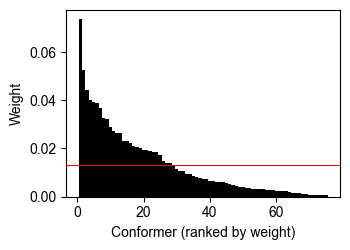

In [3]:
fig, ax = plt.subplots(figsize=(3.6, 2.6))
order = np.argsort(w)[::-1]
ax.bar(np.arange(1, len(w) + 1), w[order], width=1.0, color="black")
ax.axhline(1 / len(w), color="red", lw=0.8, zorder=3)
ax.set_xlabel("Conformer (ranked by weight)")
ax.set_ylabel("Weight")
plt.tight_layout()
plt.show()

The red line is the uniform weight, 1/N.

## Using the weights

Every SOURSOP method that computes an ensemble average accepts `weights=`, and PED's normalised weights can be passed straight in.

In [4]:
protein = ped.load_ensemble(IDENTIFIER, cache_dir=CACHE).proteinTrajectoryList[0]
print(f"{protein.n_frames} conformers, {protein.n_residues} residues")

rg = protein.get_radius_of_gyration()
re = protein.get_end_to_end_distance(mode="CA")
print(f"<Rg>: unweighted {rg.mean():.1f} A, weighted {protein.get_radius_of_gyration(weights=w):.1f} A")
print(f"<Re>: unweighted {re.mean():.1f} A, weighted {protein.get_end_to_end_distance(mode='CA', weights=w):.1f} A")

75 conformers, 130 residues
<Rg>: unweighted 37.5 A, weighted 35.9 A
<Re>: unweighted 85.1 A, weighted 80.4 A


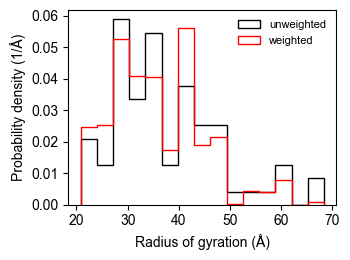

In [5]:
bins = np.linspace(rg.min(), rg.max(), 16)
fig, ax = plt.subplots(figsize=(3.6, 2.7))
ax.hist(rg, bins=bins, density=True, histtype="step", color="black", label="unweighted")
ax.hist(rg, bins=bins, weights=w, density=True, histtype="step", color="red", label="weighted")
ax.set_xlabel("Radius of gyration (Å)")
ax.set_ylabel("Probability density (1/Å)")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

The weights shift the ensemble towards more compact conformers. The distance map shows which residue pairs the reweighting moved closer together (blue) or further apart (red).

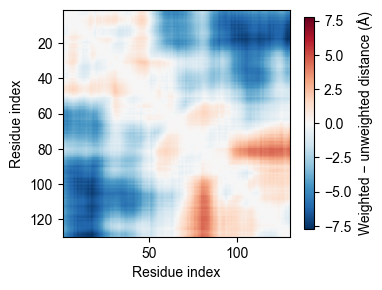

In [6]:
unweighted, _ = protein.get_distance_map(mode="CA", verbose=False)
weighted, _ = protein.get_distance_map(mode="CA", weights=w, verbose=False)
diff = (weighted - unweighted) + (weighted - unweighted).T
limit = np.abs(diff).max()
n = protein.n_residues

fig, ax = plt.subplots(figsize=(3.9, 3.2))
im = ax.imshow(diff, cmap="RdBu_r", vmin=-limit, vmax=limit, extent=[1, n, n, 1])
ax.set_xlabel("Residue index")
ax.set_ylabel("Residue index")
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Weighted − unweighted distance (Å)")
plt.tight_layout()
plt.show()

## Larger reweighted ensembles

The same works for large ensembles. `PED07323` is a 988-conformer molecular dynamics ensemble of human IAPP, reweighted against experimental data (about 40 MB to download).

In [7]:
w_iapp = ped.get_ensemble_weights("PED07323e001")
iapp = ped.load_ensemble("PED07323e001", cache_dir=CACHE).proteinTrajectoryList[0]
print(f"{iapp.n_frames} conformers, effective number {1 / np.sum(w_iapp**2):.0f}")
print(f"<Rg>: unweighted {iapp.get_radius_of_gyration().mean():.2f} A, "
      f"weighted {iapp.get_radius_of_gyration(weights=w_iapp):.2f} A")

988 conformers, effective number 138
<Rg>: unweighted 13.55 A, weighted 13.69 A


PED also serves weights for ensembles whose conformers are equally likely, so an unweighted ensemble simply returns uniform weights:

In [8]:
print(ped.get_ensemble_weights("PED00001e001"))

[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]


## Saving files

`ped.download_ensemble()` saves an ensemble as a multi-model PDB file (`<identifier>.pdb`) and returns its path. If the file is already there, it is reused rather than downloaded again. The file can be read back in with `SSTrajectory` like any other PDB file, or opened in PyMOL, VMD and so on.

In [9]:
path = ped.download_ensemble("PED00001e001", directory=CACHE)
print(path)

traj = SSTrajectory(path, path)
print(traj)

ped_cache/PED00001e001.pdb
SSTrajectory (0x111520ce0): 1 proteins and 11 frames


`ped.download_all_data()` downloads everything PED holds for an ensemble in a single `.tar.gz`: the ensemble itself and its weights.

In [10]:
import tarfile

archive = ped.download_all_data("PED00001e001", directory=CACHE)
print(archive)
with tarfile.open(archive) as tar:
    for member in tar.getmembers():
        print(f"  {member.name:20s} {member.size / 1e3:8.1f} kB")

ped_cache/PED00001e001_all_data.tar.gz
  ensemble.tar.gz         254.5 kB
  weights.tsv               0.2 kB


## When things go wrong

Every failure raises `ped.PEDError`, a subclass of SOURSOP's `SSException`. Its `status` attribute holds the HTTP status code (`404` for something that does not exist), or `None` if PED could not be reached.

In [11]:
try:
    ped.get_entry("PED99999")
except ped.PEDError as error:
    print("status:", error.status)
    print(error)

status: 404
PED has no such resource (HTTP 404): https://deposition.proteinensemble.org/v1/entries/PED99999
